In [2]:
import matplotlib.pyplot as plt
import pylab
import os

In [31]:
prename = r"/home/kelsey/GitScripts/ActiveScripts/Python/Sh0136"
file_path = os.path.join(prename)
pfx = "Sun_"                                  #Use the prefix for the file here, like PS or Sun #pfx = "\\PS_"
postname = "_-42C"
detno = "Sh0136"
title = detno + " Pre-Post Dice IV Curve " + postname       #Name the plot title displayed on the plot
filename = "Allstrips" + postname + "slides" #Give the png file a name, the file will be named detno + " " + filename
savename = os.path.join(prename,filename)

lets = ['A_PreDice','F_PreDice','H_PreDice','A1','A2','F1','F2','H1','H2']    #8-strip detector
shapes = ['o','o','o','x','x','x','x','x','x']
#lets = ['A','B','C','D','R']                   #4-strip detector

cols = ['blue','red','orange','tab:blue','tab:blue','darkred','darkred','gold','gold']

Path exists: /home/kelsey/GitScripts/ActiveScripts/Python/Sh0136
/home/kelsey/GitScripts/ActiveScripts/Python/Sh0136/Sun__-42C.txt
A_PreDice:	0.1403
F_PreDice:	0.0008
H_PreDice:	0.1521
A1:	0.0034
A2:	0.0008
F1:	0.0002
F2:	0.0002
H1:	0.0326
H2:	0.3066


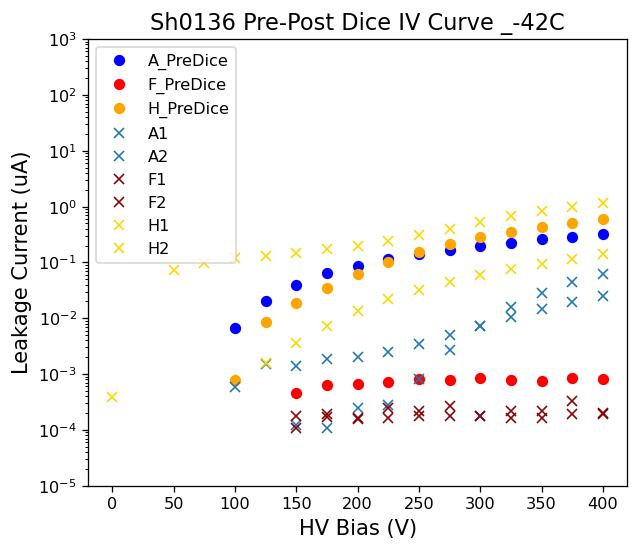

In [32]:
if os.path.exists(file_path):
    print(f"Path exists: {file_path}")
    ylow = 1e-5
    yhigh = 1000
    plt.figure(figsize=(6, 5),dpi=116)
    plt.yscale('log')
    plt.xlabel("HV Bias (V)",fontsize=13)
    plt.ylabel("Leakage Current (uA)",fontsize=13)
    plt.ylim(ylow,yhigh)
    plt.title(title,fontsize=14)

    txtname = os.path.join(prename,pfx+postname+".txt")
    print(txtname)
    f = open(txtname,"w")
    f.write("")
    f.close()

    for j, x in enumerate(lets):
        name = os.path.join(prename,pfx+lets[j]+postname)
        #print(name)
        nlines = len(open(name).readlines(  ))
        pltfile = open(name, "r")
        tarray = [0]*3
        V = [0]*nlines #Could also probably accomplish this within the array with a function that adds another element to the array.
        I = [0]*nlines
    
        for i, x in enumerate(pltfile):
            tarray = x.strip().split(',')
            V[i] = float(tarray[1])
            I[i] = float(tarray[2])
        print(lets[j] + ":\t"+ str(round(I[10],4)))
        f = open(txtname,"a")
        f.write(lets[j] + "\t" + str(round(I[10],4)) + "\n")
        f.close()
    
        #plt.plot(V, I, 'o', label = lets[j])    
        plt.plot(V, I, shapes[j], label = lets[j], color=cols[j]) #Can uncomment this if for whatever reason you'd like colors on your plot. 
        pltfile.close()


    plt.legend(loc='upper left')
    plt.savefig(savename) #Save the file
    plt.show() #Display the plot
else:
    print(f"Path does not exist: {file_path}")